# LAB06 Assigment




### Exercise 1 Linear Discriminant Analysis from Scratch using numpy (50 points )
- <font size=4> Complete the missing code in the LDA class below<font>

In [45]:
import numpy as np
import matplotlib.pyplot as plt


class LDA:
    #n_components:Number of components (<= min(n_classes - 1, n_features)) for dimensionality reduction.
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.eigenvalues = None
        self.eigenvectors = None

    def fit(self, X, y):
        # Convert X and y to numpy arrays
        X = np.asarray(X)
        y = np.asarray(y)

        n_features = np.shape(X)[1]
        labels = np.unique(y)

        # The maximum number of components is the minimum of (number of classes - 1) and (number of features)
        max_components = min(len(labels) - 1, n_features)


        if self.n_components is None or self.n_components > X.shape[1]:
            n_components = max_components
        else:
            n_components = min(self.n_components, max_components)
  
        # Within class scatter matrix
        # Complete code for calculating S_W
        ########### Write Your Code Here ###########

        # S_W: evaluate the within class scatter matrix, which is the sum of the covariance matrices of each class
        S_W = np.zeros((n_features, n_features))
        
        # 
        S_B = np.zeros((n_features, n_features))

        # axis=0 means we are calculating the mean for each column (feature) across all samples
        overall_mean = np.mean(X, axis=0)

        for label in labels:
            # Get the samples of the current class
            X_c = X[y == label]

            # Calculate the mean of the current class
            class_mean = np.mean(X_c, axis=0)

            # Calculate the covariance matrix for the current class
            X_centered = X_c - class_mean
            # Update the within class scatter matrix by adding the covariance matrix of the current class
            S_W += X_centered.T @ X_centered

            # Calculate the mean difference between the current class mean and the overall mean
            mean_diff = (class_mean - overall_mean).reshape(n_features, 1)

            # Between class scatter matrix
            # Complete code for calculating S_B
            ########### Write Your Code Here ###########
            
            # 
            S_B +=X_c.shape[0] * (mean_diff @ mean_diff.T)

      
        # Determine SW^-1 * SB by calculating inverse of SW
        ########### Write Your Code Here ###########

        # use pesudo-inverse in case SW is singular
        S_W_inv = np.linalg.inv(S_W)
        mat = S_W_inv @ S_B

        # Get eigenvalues and eigenvectors of SW^-1 * SB
        ########### Write Your Code Here ###########

        # calculate the eigenvalues and eigenvectors of the matrix mat
        # eigenvalues: the eigenvalues of the matrix mat
        # which represent the amount of variance explained by each linear discriminant
        # eigenvectors: the eigenvectors of the matrix mat
        # which represent the directions of the linear discriminants in the feature space
        # the larger the eigenvalue, the more variance is explained by the corresponding eigenvector
        eigenvalues, eigenvectors = np.linalg.eig(mat)

        # Make sure eigenvalues and eigenvectors are real numbers
        eigenvalues = np.real_if_close(eigenvalues)
        eigenvectors = np.real_if_close(eigenvectors)

        # Sort the eigenvalues and corresponding eigenvectors from largest
        # to smallest eigenvalue and select the first n_components
        idx = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[idx][:n_components]
        eigenvectors = eigenvectors[:, idx][:, :n_components]
  
        self.eigenvalues = eigenvalues
        self.eigenvectors = eigenvectors

        return self
  
    def fit_transform(self, X, y):
        ########### Write Your Code Here ###########

        # fit the model to the data and then transform the data using the fitted model
        self.fit(X, y)
        
        return self.transform(X)
  
    def transform(self, X):
        ########### Write Your Code Here ###########

        # fit must be called before transform, so we check if eigenvectors are available
        if self.eigenvectors is None:
            raise ValueError("The model has not been fitted yet. Please call fit() before transform().")
        
        X = np.asarray(X)

        # Project the data onto the eigenvectors
        return X @ self.eigenvectors  

- <font size=4> Dimensionality reduction visualization<font>

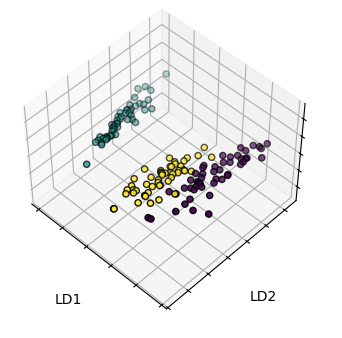

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets

np.random.seed(5)


iris = datasets.load_iris()
# X: the data to be transformed, shape (n_samples, n_features)
X = iris.data
# y: the class labels, shape (n_samples,)
y = iris.target

# for 3 classes, the maximum number of components is 2, so we set n_components to 2
lda = LDA(n_components=2)
# fit the model to the data and then transform the data using the fitted model
lda.fit(X, y)
X_lda = lda.transform(X)

X_plot = np.hstack([X_lda, np.zeros((X_lda.shape[0], 1))])

fig = plt.figure(1, figsize=(4, 3))
ax = fig.add_subplot(111, projection="3d", elev=48, azim=134)
ax.set_position([0, 0, 0.95, 1])

# for each class, we plot the samples in the 3D space defined by the first two linear discriminants and a zero z-axis
for name, label in [('Setosa', 0), ('Versicolour', 1), ('Virginica', 2)]:
    ax.text3D(
        X_plot[y == label, 0].mean(),
        X_plot[y == label, 1].mean(),
        X_plot[y == label, 2].mean() + 0.2, # add some offset to the z-axis for better visualization
        name,
        horizontalalignment='center',
        bbox=dict(alpha=0.5, edgecolor='w', facecolor='w')
    )

# we use np.choose to map the class labels to colors for better visualization
y_color = np.choose(y, [1, 2, 0]).astype(float)

# plot the samples in the 3D space defined by the first two linear discriminants and a zero z-axis
# colored by their class labels
ax.scatter(X_plot[:, 0], X_plot[:, 1], X_plot[:, 2], c=y_color, edgecolor='k')

# remove tick labels for better visualization
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# set labels for the axes
ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_zlabel("Aux axis (0 padded)")
ax.dist = 12

plt.show()

plt.show()

### Exercise 2 Recognize handwritten numbers with LDA (50 points ). 

Your task in this section is to recognize handwritten numbers, and you can use the linear discriminant analysis model from the Scikit-Learn library to fit, evaluate, and predict them.

<font color='red' size=4>Note that your accuracy in this section will directly determine your score.</font>

### Loading the MNIST Dataset


In [47]:
########### Write Your Code Here ###########

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# fetch the MNIST dataset, which contains 70,000 images of handwritten digits (0-9)
# with 784 features (28x28 pixels) and 10 classes (digits 0-9)
mnist = datasets.fetch_openml('mnist_784', version=1, parser='auto', as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print(f"Total samples: {X.shape[0]}")
print(f"Features per sample: {X.shape[1]}")
print(f"Number of classes: {len(set(y))}")

# normalization is important for LDA
# so we standardize the features to have mean 0 and variance 1
scalar = StandardScaler()
X = scalar.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

############################################

Total samples: 70000
Features per sample: 784
Number of classes: 10

Training set size: 49000
Test set size: 21000


###  Visualization of MINIST

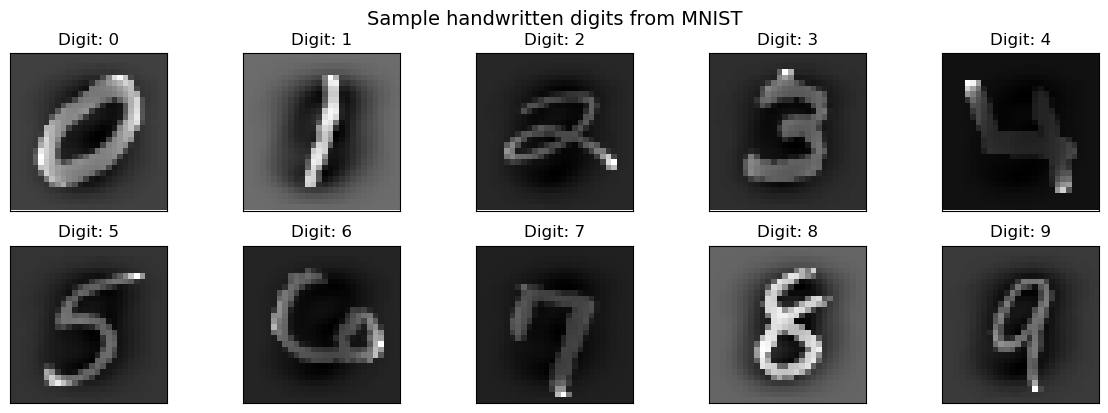

Visualization complete. Each image is a 28x28 pixel grayscale digit.


In [48]:
# Visualize MINIST
########### Write Your Code Here ###########

import matplotlib.pyplot as plt
import numpy as np

# we create a 2x5 grid of subplots to visualize the first 10 samples of the MNIST dataset
# figsize=(12, 4) means the figure will be 12 inches wide and 4 inches tall
# axes.ravel() flattens the 2D array of axes into a 1D array for easier indexing
fig, axes = plt.subplots(2, 5, figsize=(12, 4))
axes = axes.ravel()

# find the indices of the first 10 samples for each digit (0-9) in the training set
for digit in range(10):
    # get the index of the first sample in the training set that belongs to the current digit
    idx = np.where(y_train == digit)[0][0]

    # reshape the 784 features back to a 28x28 image
    image = X_train[idx].reshape(28, 28)

    # display the image in grayscale
    axes[digit].imshow(image, cmap='gray') 

    # set the title of the subplot to the digit label
    axes[digit].set_title(f"Digit: {digit}")

    # remove the tick marks for better visualization
    axes[digit].set_xticks([])
    axes[digit].set_yticks([])

plt.tight_layout()
plt.suptitle("Sample handwritten digits from MNIST", fontsize=14, y=1.02)
plt.show()

print("Visualization complete. Each image is a 28x28 pixel grayscale digit.")


############################################

### Fit  Model

In [49]:
########### Write Your Code Here ###########

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(
    n_components=None # number of components (<= min(n_classes - 1, n_features)) for dimensionality reduction
)

# in this step, we will train the LDA model using the training data (X_train and y_train):
# 1. compute the within-class scatter matrix (S_W) and between-class scatter matrix (S_B) using the training data
# 2. compute the eigenvalues and eigenvectors of the matrix S_W^-1 * S_B
# 3. sort the eigenvalues and corresponding eigenvectors in descending order
# and select the top n_components eigenvectors to form the transformation matrix
print("Training LDA model...")
lda.fit(X_train, y_train)

print(f"Model fitted successfully!")
print(f"Number of components used: {lda.n_components}")

# the number of classes and the class labels in the training data
print(f"Number of classes: {len(lda.classes_)}")
print(f"Classes: {lda.classes_}")

# the shape of the projection matrix (eigenvectors) used for dimensionality reduction
print(f"Projection matrix shape: {lda.coef_.shape}")

############################################

Training LDA model...
Model fitted successfully!
Number of components used: None
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
Projection matrix shape: (10, 784)


## Evaluate model

Accuracy on test set: 0.1016

Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      2058
           1     0.0000    0.0000    0.0000      2364
           2     0.1016    0.9995    0.1844      2133
           3     0.0000    0.0000    0.0000      2176
           4     0.0000    0.0000    0.0000      1936
           5     0.0000    0.0000    0.0000      1915
           6     0.0000    0.0000    0.0000      2088
           7     0.0000    0.0000    0.0000      2248
           8     0.0000    0.0000    0.0000      1992
           9     0.2000    0.0005    0.0010      2090

    accuracy                         0.1016     21000
   macro avg     0.0302    0.1000    0.0185     21000
weighted avg     0.0302    0.1016    0.0188     21000



/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

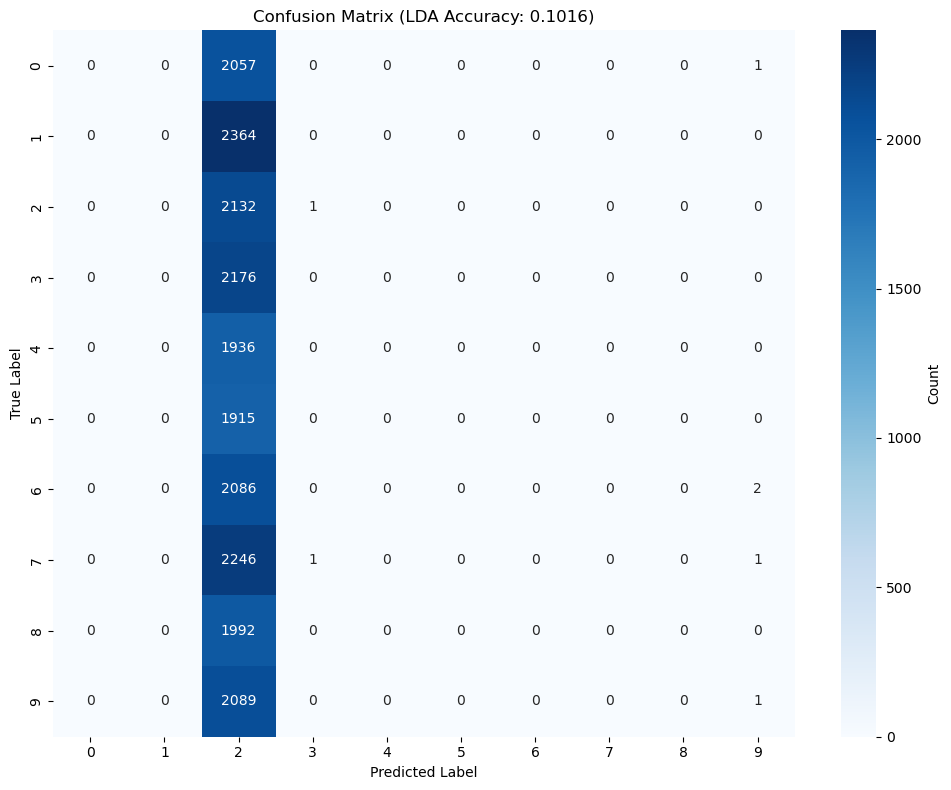


Macro-averaged Precision: 0.0302
Macro-averaged Recall: 0.1000
Macro-averaged F1-score: 0.0185

Training set accuracy: 0.0991
Difference (training - test): -0.0024
✓ Model generalization looks good


/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [50]:
########### Write Your Code Here ###########
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 预测：用训练好的 LDA 模型在测试集上进行预测
y_pred = lda.predict(X_test)

# 基本准确率
# accuracy 是最直观的指标：在所有预测中有多少是对的
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on test set: {accuracy:.4f}")

# 更详细的分类报告
# 包括 precision（精准率）、recall（召回率）、f1-score（调和平均）等
# 对于多分类任务，这里会给出每一类的独立指标
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# 混淆矩阵：显示每一类预测对/错的情况
# 对角线是预测正确的数量，非对角线是预测错误的数量
cm = confusion_matrix(y_test, y_pred)

# 可视化混淆矩阵（热力图）
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,  # 在每个格子里显示数字
    fmt='d',     # 格式：整数
    cmap='Blues', # 颜色方案
    xticklabels=range(10),
    yticklabels=range(10),
    cbar_kws={'label': 'Count'}
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix (LDA Accuracy: {accuracy:.4f})")
plt.tight_layout()
plt.show()

# 计算宏平均（macro）和微平均（micro）的精准率和召回率
# macro：对每一类的指标直接平均
# micro：用全局的 TP/FP/FN 来计算
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"\nMacro-averaged Precision: {precision_macro:.4f}")
print(f"Macro-averaged Recall: {recall_macro:.4f}")
print(f"Macro-averaged F1-score: {f1_macro:.4f}")

# 训练集表现（用来检查是否过拟合）
y_train_pred = lda.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nTraining set accuracy: {train_accuracy:.4f}")

# 过拟合判断：如果训练准确率和测试准确率接近，说明模型泛化能力较好
print(f"Difference (training - test): {train_accuracy - accuracy:.4f}")
if train_accuracy - accuracy > 0.1:
    print("⚠️ Warning: Possible overfitting detected")
else:
    print("✓ Model generalization looks good")
############################################


### Exercise 3: Qustions
- Q1:What are the advantages and disadvantages of LDA?


- Q2 LDA can be used for dimensionality reduction, so can PCA. Please tell the difference between them?